In [25]:
#Leaky integrate-and-fire neuron, lif from canvas notes

import numpy as np
import matplotlib.pyplot as plt


__all__ = ["lif_sim"]


def lif_sim(I=1.1, T=10.0, dt=1e-3, taum=1.0, R=1.0, urest=0.0, uth=1.0,
            sigma=0.0, seed=None, reset=False):
   
    rng = np.random.default_rng(seed)
    Ifun = I if callable(I) else (lambda t: I)

    nt = int(round(T / dt)) + 1
    t = np.linspace(0.0, T, nt)
    u = np.zeros(nt)
    u[0] = urest
    spikes = []

    for j in range(nt - 1):
        du = dt * (R * Ifun(t[j]) - (u[j] - urest)) / taum
        if sigma:
            du += np.sqrt(2 * dt) * sigma * rng.standard_normal()
        u[j + 1] = u[j] + du
        if reset and u[j + 1] > uth:
            u[j + 1] = urest
            spikes.append(t[j + 1])

    spikes = np.array(spikes)
    rate = 1000 * (len(spikes) - 1) / (spikes[-1] - spikes[0]) if len(spikes) >= 2 else 0.0
    return t, u, spikes, rate


Reported Values:
 t_peak = 4.0236
I0_crit = 7.4767


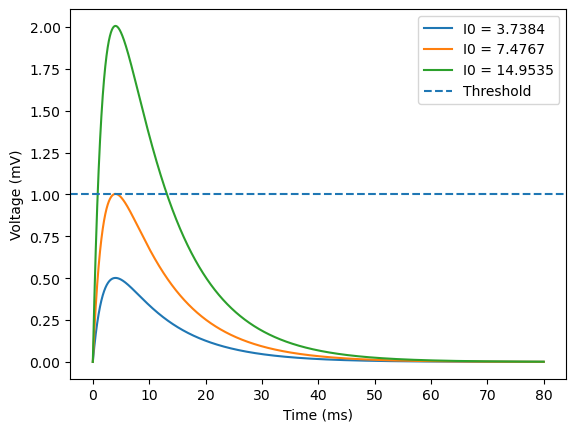


Numerical results:
I0		 tpeak		 Peak u		 Ana u
3.7384		 4.0200		 0.5014		 0.5000
7.4767		 4.0200		 1.0029		 1.0000
14.9535		 4.0200		 2.0058		 2.0000


In [26]:
R = 1.0
taum = 10.0
tau_s = 2.0
urest = 0.0
uth = 1.0
T_sim = 80.0    
dt    = 0.01  

r = tau_s / taum

t_peak = (taum * tau_s) / (tau_s - taum) * np.log(tau_s /  taum)

factor = r ** (-1.0 / (r- 1.0))

I0_crit = uth / (R * factor)

print("Reported Values:")
print(f" t_peak = {t_peak:.4f}")
print(f"I0_crit = {I0_crit:.4f}")

amplitudes = [0.5 * I0_crit, I0_crit, 2.0 * I0_crit]
amp_labels = ["0.5 x I₀_crit", "1.0 x I₀_crit", "2.0 x I₀_crit"]
colors     = ["#5B8DB8", "#E07B39", "#55A868"]

results =[]

for I0, lbls in zip(amplitudes, amp_labels):

    I0_current = lambda t, _I0=I0: _I0* np.exp(-t / tau_s)

    t, u, spikes, rate = lif_sim(
        I=I0_current,
        T=T_sim,
        dt=dt,
        taum=taum,
        R=R,
        urest=urest,
        uth=uth,
    )

    idx = np.argmax(u)
    t_pk_num = t[idx]
    u_pk_num = u[idx]
    u_pk_ana = R * I0 * factor   

    results.append(
        (I0, t_pk_num, u_pk_num, u_pk_ana)
    )

    plt.plot(t, u, label=f"I0 = {I0:.4f}")


plt.axhline(uth, linestyle="--", label="Threshold")

plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.show()

print("\nNumerical results:")
print("I0\t\t tpeak\t\t Peak u\t\t Ana u")

for I0, tpeak_num, peak_num, peak_ana in results: 
    print(f"{I0:.4f}\t\t {tpeak_num:.4f}\t\t {peak_num:.4f}\t\t {peak_ana:.4f}")

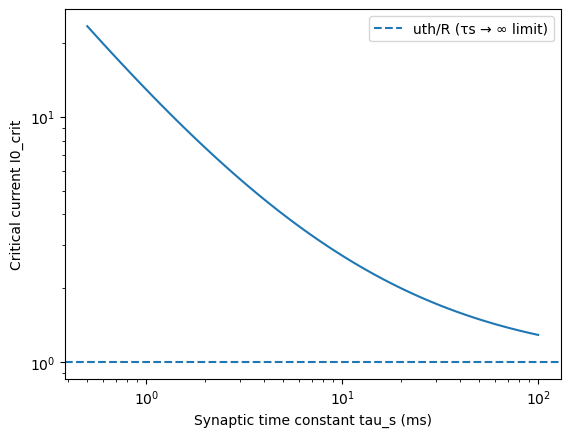

In [27]:
tau_s_values = np.logspace(np.log10(0.5), np.log10(100), 100)

I0_crit_values = []

for tau_s in tau_s_values:
    r = tau_s / taum
    factor = r ** (-1.0 / (r - 1.0))
    I0_crit = uth / (R * factor)
    I0_crit_values.append(I0_crit)


#plot I0crit vs tau_s
plt.figure()

plt.loglog(tau_s_values, I0_crit_values)
plt.axhline(uth / R, linestyle="--", label="uth/R (τs → ∞ limit)") 
plt.legend()
plt.xlabel("Synaptic time constant tau_s (ms)")
plt.ylabel("Critical current I0_crit")
plt.show()

As the tau_s decreases towards 0 and gets very small, the input current becomes more and more brief. This means you may need a larger inital current to reach that threshold. On the other side, as tau_s goes to infinity, the synaptic current starts to become constant. This is supported by the shape of the curve in the plot above.